In [62]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from YParams import YParams
from utils import *
from data_utils.data_loaders import *
from data_utils.data_utils import (
    MaskerNonuniformMesh,
    MaskerUniform,
    MaskerUniformIndependent,
    batched_masker,
)
plt.rcParams["figure.figsize"] = (12.5,2.25)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
params = YParams('./config/ssl_ns_elastic.yaml', 'codano_test', print_params=False)

In [3]:
mesh = get_mesh(params.input_mesh_location)

In [4]:
mesh.shape

(1317, 2)

In [ ]:
print(list(params.equation_dict.keys()))
dataset = NsElasticDataset(params.data_location, equation=list(params.equation_dict.keys()), mesh_location=params.input_mesh_location)
params.dt = 100
train, test = dataset.get_dataloader(params.mu_list, params.dt, ntrain=params.get(
        'ntrain'), ntest=params.get('ntest'), sample_per_inlet=params.sample_per_inlet)

In [6]:
mesh = torch.from_numpy(mesh).float()
print(mesh.shape)

torch.Size([1317, 2])


In [ ]:
for data in train:
    x, y = data['x'], data['y']
    dx_mesh = data['d_grid_x'][0]
    dy_mesh = data['d_grid_y'][0]
    print(mesh.shape, dx_mesh.shape, dy_mesh.shape, x.shape,y.shape)
    print(torch.min(dx_mesh[:,0]), torch.min(dx_mesh[:,1]))
    plt.scatter(mesh[:,0]+dx_mesh[:,0], mesh[:,1]+dx_mesh[:,1],c=dx_mesh[:,0], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()
    plt.scatter(mesh[:,0]+dy_mesh[:,0], mesh[:,1]+dy_mesh[:,1],c=y[0,:,-2], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()

In [8]:
## making uniform mesh
mesh_ = get_mesh(params.input_mesh_location)
minx, maxx = np.min(mesh_[:, 0]), np.max(mesh_[:, 0])
miny, maxy = np.min(mesh_[:, 1]), np.max(mesh_[:, 1])

size_x, size_y = params.grid_size
idx_x = torch.arange(
start=minx,
end=maxx + (maxx - minx) / size_x - 1e-5,
step=(maxx - minx) / (size_x - 1),
)
idx_y = torch.arange(
start=miny,
end=maxy + (maxy - miny) / size_y - 1e-5,
step=(maxy - miny) / (size_y - 1),
)
x, y = torch.meshgrid(idx_x, idx_y, indexing='ij')
output_mesh = torch.transpose(
torch.stack([x.flatten(), y.flatten()]),
dim0=0,
dim1=1,
).type(torch.float)

In [63]:
augmenter = MaskerNonuniformMesh(
                grid_non_uni=mesh,
                gird_uni=output_mesh,
                radius=params.masking_radius,
                drop_type=params.drop_type,
                drop_pix=params.drop_pix,
                channel_aug_rate=params.channel_per,
                channel_drop_rate=params.channel_drop_per,
            )

Masking
Masking
Masking


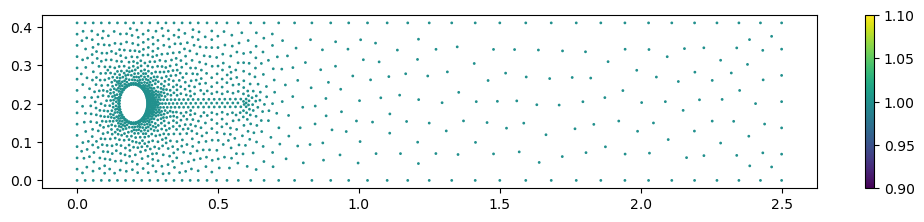

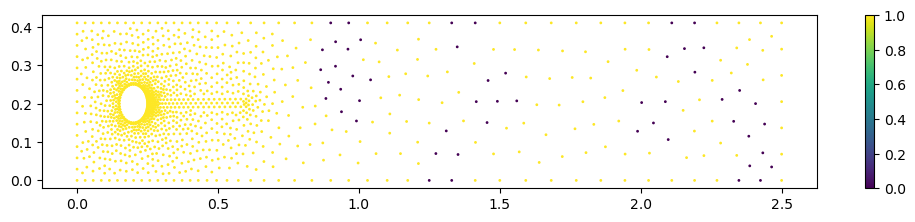

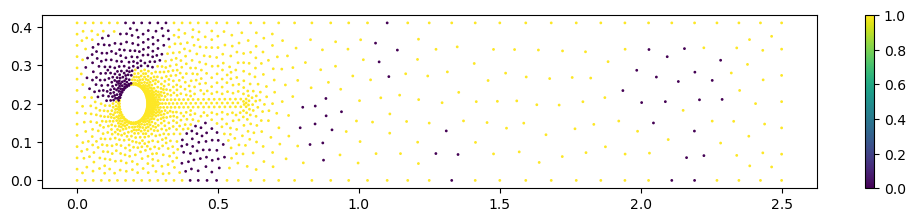

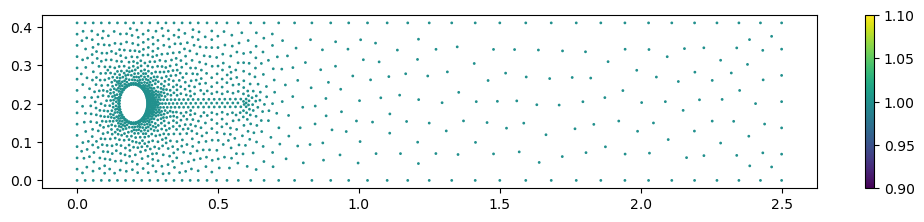

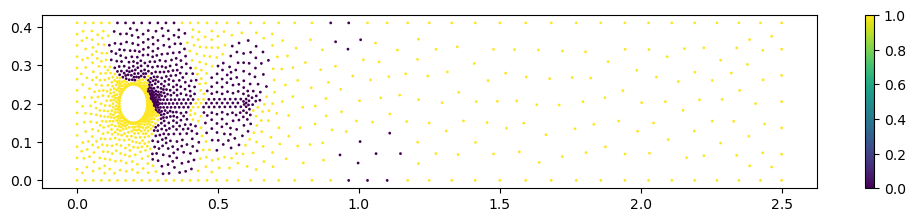

In [68]:
for data in test:
    x, y = data['x'], data['y']
    dx_mesh = data['d_grid_x'][0]
    dy_mesh = data['d_grid_y'][0]
    x_masked, masks = batched_masker(
                x,
                augmenter,
                batched_channels=None,
            )
    for i in range(x_masked.shape[-1]):
        plt.scatter(mesh[:,0]+dx_mesh[:,0], mesh[:,1]+dx_mesh[:,1],c=masks[0,:,i], cmap='viridis', s=1.0)
        plt.colorbar()
        plt.show()
    break
